In [15]:
import numpy as np
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [20]:
stations_CTA = np.loadtxt('data/points/CTAHiDim.txt', delimiter=",", skiprows=1)


In [21]:
# alpha
alpha_CTA = gd.AlphaComplex(points=stations_CTA)
tree_CTA_alpha = alpha_CTA.create_simplex_tree()
barcodes_CTA_alpha = tree_CTA_alpha.persistence()

<Axes: title={'center': 'Persistence density'}, xlabel='Birth', ylabel='Death'>

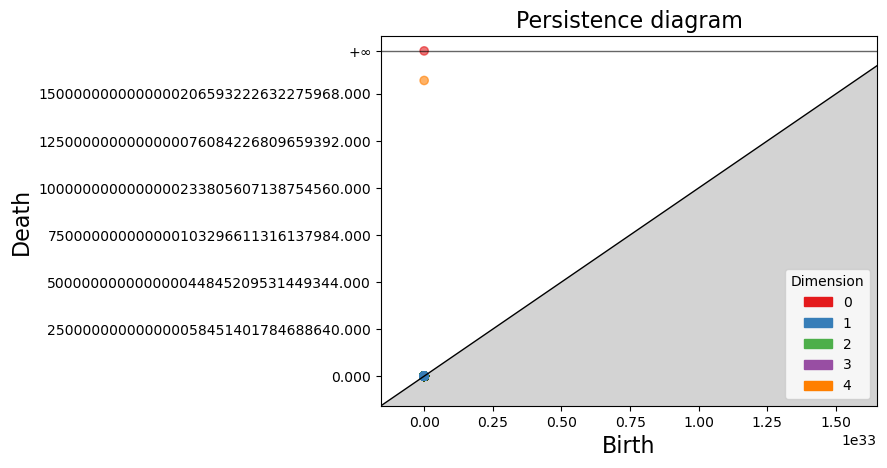

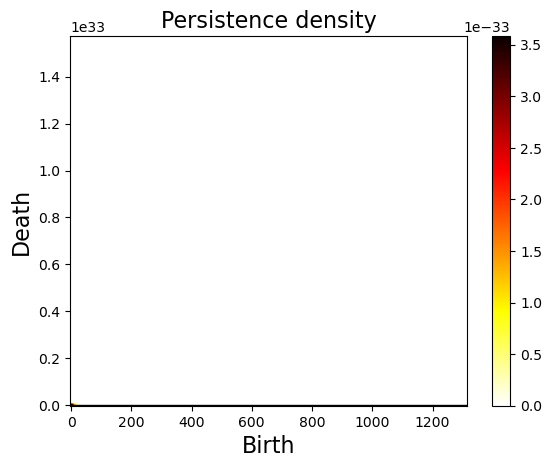

In [26]:

gd.plot_persistence_diagram(barcodes_CTA_alpha, max_intervals=6000)

gd.plot_persistence_density(barcodes_CTA_alpha, max_intervals=6000)


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

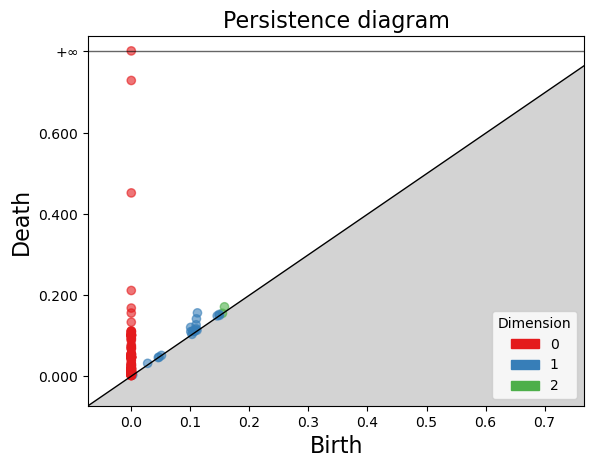

In [24]:
# alpha
rips_CTA = gd.RipsComplex(points=stations_CTA)
tree_CTA_rips = rips_CTA.create_simplex_tree(max_dimension=4)
barcodes_CTA_rips = tree_CTA_rips.persistence()

gd.plot_persistence_diagram(barcodes_CTA_rips)

In [28]:
Ista1_CTA = tree_CTA_alpha.persistence_intervals_in_dimension(4)
Ista0_CTA = tree_CTA_alpha.persistence_intervals_in_dimension(3)
lifetimes1_CTA = Ista1_CTA[:,1] - Ista1_CTA[:,0]
order_CTA = np.argsort(lifetimes1_CTA)[::-1]
order0_CTA = np.sort(Ista0_CTA)[::-1]
Ista_sorted1_CTA = Ista1_CTA[order_CTA]
print(Ista_sorted1_CTA)

[[9.68146916e-02 1.57053186e+33]
 [8.77632097e-02 1.91533638e+05]
 [2.27272578e-02 9.77432631e+04]
 ...
 [3.64848329e-02 3.64939069e-02]
 [4.06869134e-02 4.06916553e-02]
 [5.82304110e-03 5.82410660e-03]]


<Axes: title={'center': 'Persistence density'}, xlabel='Birth', ylabel='Death'>

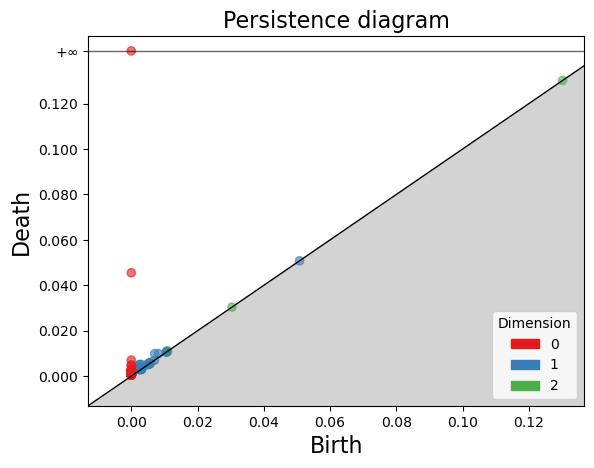

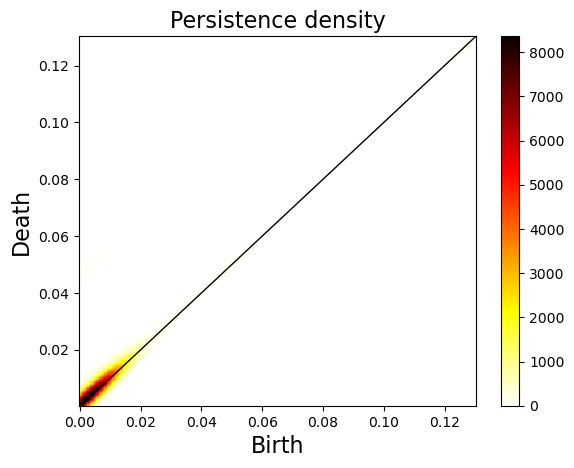

In [30]:
last_three = stations_CTA[:, -3:]


# alpha
alpha_CTA = gd.AlphaComplex(points=last_three)
tree_CTA_alpha = alpha_CTA.create_simplex_tree()
barcodes_CTA_alpha = tree_CTA_alpha.persistence()


gd.plot_persistence_diagram(barcodes_CTA_alpha, max_intervals=6000)

gd.plot_persistence_density(barcodes_CTA_alpha, max_intervals=6000)


In [35]:
stations_CTA1= copy(stations_CTA)

lat_min, lat_max = stations_CTA[:,0].min(), stations_CTA[:,0].max()
lon_min, lon_max = stations_CTA[:,1].min(), stations_CTA[:,1].max()

stations_CTA1[:,0] = (stations_CTA[:,0] - lat_min) / (lat_max - lat_min)
stations_CTA1[:,1] = (stations_CTA[:,1] - lon_min) / (lon_max - lon_min)


# alpha
alpha_CTA1 = gd.AlphaComplex(points=stations_CTA1)
tree_CTA_alpha1 = alpha_CTA1.create_simplex_tree()
barcodes_CTA_alpha1 = tree_CTA_alpha1.persistence().drop([1.27449312e-01, 4.44193845e+34])

gd.plot_persistence_diagram(barcodes_CTA_alpha1)


Ista1_CTA1 = tree_CTA_alpha1.persistence_intervals_in_dimension(4)
Ista0_CTA1 = tree_CTA_alpha1.persistence_intervals_in_dimension(3)
lifetimes1_CTA1 = Ista1_CTA1[:,1] - Ista1_CTA1[:,0]
order_CTA1 = np.argsort(lifetimes1_CTA1)[::-1]
order0_CTA1 = np.sort(Ista0_CTA1)[::-1]
Ista_sorted1_CTA1 = Ista1_CTA1[order_CTA1]
print(Ista_sorted1_CTA1)



AttributeError: 'list' object has no attribute 'drop'